In [1]:
import networkx as nx
from dataclasses import dataclass
from typing import Any, Dict

#BUILDING ZX GRAPH & Z-SPIDER FUSION RULES 

@dataclass(frozen=True)
class Phase:
    value: int = 0
    mod: int = 3
    def __add__(self, other: "Phase") -> "Phase":
        if self.mod != other.mod:
            raise ValueError("Phase mod mismatch")
        return Phase((self.value + other.value) % self.mod, self.mod)

def metrics(G: nx.MultiGraph) -> Dict[str, int]:
    kinds = [G.nodes[n].get("kind") for n in G.nodes]
    return {
        "nodes": G.number_of_nodes(),
        "edges": G.number_of_edges(),
        "Z": sum(k == "Z" for k in kinds),
        "boundary": sum(k == "boundary" for k in kinds),
    }

def fuse_Z_pair(G: nx.MultiGraph, keep: Any, remove: Any) -> None:
    p_keep: Phase = G.nodes[keep].get("phase", Phase(0))
    p_remove: Phase = G.nodes[remove].get("phase", Phase(0))
    G.nodes[keep]["phase"] = p_keep + p_remove

    for nb in list(G.neighbors(remove)):
        if nb == keep:
            continue
        for _key, edata in list(G[remove][nb].items()):
            G.add_edge(keep, nb, etype=edata.get("etype", "plain"))

    G.remove_node(remove)

def apply_Z_fusion_to_fixed_point(G: nx.MultiGraph, max_iters: int = 100000) -> int:
    fusions = 0
    for _ in range(max_iters):
        did = False
        for u, v, k, edata in list(G.edges(keys=True, data=True)):
            if not (G.has_node(u) and G.has_node(v) and G.has_edge(u, v, key=k)):
                continue
            if G.nodes[u].get("kind") == "Z" and G.nodes[v].get("kind") == "Z":
                if edata.get("etype", "plain") == "plain":
                    fuse_Z_pair(G, keep=u, remove=v)
                    fusions += 1
                    did = True
                    break
        if not did:
            break
    return fusions

#BUILDING 3-QUTRIT QFT

def build_qft3_zx_graph_sixZ() -> nx.MultiGraph:
    G = nx.MultiGraph()

    # boundaries (one per qutrit wire)
    for i in range(3):
        G.add_node(f"in_q{i}", kind="boundary")

    # 6 Z spiders (2 per wire)
    Zs = [
        "Z_q0_01", "Z_q0_02",
        "Z_q1_01", "Z_q1_12",
        "Z_q2_02", "Z_q2_12",
    ]
    for z in Zs:
        G.add_node(z, kind="Z", phase=Phase(0))

    # Put the two Z spiders on each wire in a chain (plain),
    # so "working down the wire" fuses them too.
    G.add_edge("Z_q0_01", "Z_q0_02", etype="plain")
    G.add_edge("Z_q1_01", "Z_q1_12", etype="plain")
    G.add_edge("Z_q2_02", "Z_q2_12", etype="plain")

    # Include Hadamards as hadamard edges from boundary into the wire chain
    G.add_edge("in_q0", "Z_q0_01", etype="hadamard")
    G.add_edge("in_q1", "Z_q1_01", etype="hadamard")
    G.add_edge("in_q2", "Z_q2_02", etype="hadamard")

    # Inter-wire controlled-phase connections:
    # (q0,q1): CPhase single edge
    G.add_edge("Z_q0_01", "Z_q1_01", etype="plain")

    # (q1,q2): CPhase single edge
    G.add_edge("Z_q1_12", "Z_q2_12", etype="plain")

    # (q0,q2): CPhase^2 double edge
    G.add_edge("Z_q0_02", "Z_q2_02", etype="plain")
    G.add_edge("Z_q0_02", "Z_q2_02", etype="plain")

    return G

if __name__ == "__main__":
    G = build_qft3_zx_graph_sixZ()
    print("Before:", metrics(G))
    f = apply_Z_fusion_to_fixed_point(G)
    print("Fusions:", f)
    print("After:", metrics(G))
    print("Remaining Z:", [n for n in G.nodes if G.nodes[n].get("kind") == "Z"])

Before: {'nodes': 9, 'edges': 10, 'Z': 6, 'boundary': 3}
Fusions: 5
After: {'nodes': 4, 'edges': 3, 'Z': 1, 'boundary': 3}
Remaining Z: ['Z_q0_01']


In [9]:
import time

#BUILDING N QUTRIT QFT FOR SCALABILITY

def build_qft_like_zx_graph(n: int, double_edges: bool = False) -> nx.MultiGraph:
    """
    Graph-only QFT-like ZX generator:
    - boundary node per wire
    - Z endpoint per ordered pair (i,j) with i<j, one on wire i and one on wire j
    - chain endpoints on each wire with plain edges (wire-local fusion)
    - connect endpoints across wires (controlled-phase edges)
    - arbitrary rule: make the (i,j) edge double when (j-i) is even 
    """
    G = nx.MultiGraph()

    # boundaries
    for i in range(n):
        G.add_node(f"in_q{i}", kind="boundary")

    # create endpoints per pair
    # store which Z nodes live on each wire, to chain them
    endpoints_on_wire = {i: [] for i in range(n)}

    for i in range(n):
        for j in range(i+1, n):
            zi = f"Z_q{i}_{i}_{j}"
            zj = f"Z_q{j}_{i}_{j}"
            G.add_node(zi, kind="Z", phase=Phase(0))
            G.add_node(zj, kind="Z", phase=Phase(0))
            endpoints_on_wire[i].append(zi)
            endpoints_on_wire[j].append(zj)

            # controlled phase edge(s)
            G.add_edge(zi, zj, etype="plain")
            if double_edges:
                # arbitrary demo rule: every other pair gets a second edge
                if (j - i) % 2 == 0:
                    G.add_edge(zi, zj, etype="plain")

    # chain endpoints along each wire
    for i in range(n):
        eps = endpoints_on_wire[i]
        # stable order (doesn't matter as much for fusion)
        eps_sorted = sorted(eps)
        for a, b in zip(eps_sorted, eps_sorted[1:]):
            G.add_edge(a, b, etype="plain")

        # include Hadamard as a hadamard edge from boundary into first endpoint (if any)
        if eps_sorted:
            G.add_edge(f"in_q{i}", eps_sorted[0], etype="hadamard")
        else:
            # n=1 edge case: boundary only
            pass

    return G

In [10]:
import statistics

def benchmark_scaling(ns=(3,5,8,10,15,20), double_edges=True, trials=15, warmup=3):
    rows = []
    for n in ns:
        trial_times = []
        fusions_last = None
        before_last = None
        after_last = None

        # warmup runs (not recording)
        for _ in range(warmup):
            G = build_qft_like_zx_graph(n, double_edges=double_edges)
            _ = apply_Z_fusion_to_fixed_point(G)

        for _ in range(trials):
            G = build_qft_like_zx_graph(n, double_edges=double_edges)
            before = metrics(G)

            t0 = time.perf_counter()
            fusions = apply_Z_fusion_to_fixed_point(G)
            t1 = time.perf_counter()

            after = metrics(G)

            trial_times.append((t1 - t0) * 1e3)
            fusions_last = fusions
            before_last = before
            after_last = after

        rows.append({
            "n_qutrits": n,
            "before_Z": before_last["Z"],
            "after_Z": after_last["Z"],
            "fusions": fusions_last,
            "before_nodes": before_last["nodes"],
            "after_nodes": after_last["nodes"],
            "time_ms_median": statistics.median(trial_times),
            "time_ms_mean": statistics.mean(trial_times),
            "time_ms_std": statistics.pstdev(trial_times),
            "time_ms_min": min(trial_times),
            "time_ms_max": max(trial_times),
        })
    return rows

In [11]:
rows = benchmark_scaling_stable(
    ns=(3,5,8,10,15,20),
    double_edges=True,
    trials=20,
    warmup=5
)

df = pd.DataFrame(rows)

# Round timing columns 
df["time_ms_median"] = df["time_ms_median"].round(3)
df["time_ms_mean"] = df["time_ms_mean"].round(3)
df["time_ms_std"] = df["time_ms_std"].round(3)

print(df.to_string(index=False))

 n_qutrits  before_Z  after_Z  fusions  before_nodes  after_nodes  time_ms_median  time_ms_mean  time_ms_std  time_ms_min  time_ms_max
         3         6        1        5             9            4           0.112         0.158        0.136     0.087375     0.723292
         5        20        1       19            25            6           0.589         0.623        0.079     0.542875     0.838167
         8        56        1       55            64            9           1.820         1.865        0.390     1.392500     2.995042
        10        90        1       89           100           11           2.907         2.900        0.037     2.809125     2.965750
        15       210        1      209           225           16          14.502        14.496        0.044    14.385000    14.579500
        20       380        1      379           400           21          46.064        46.108        0.148    45.919292    46.575250


In [14]:
clean_df = df[[
    "n_qutrits",
    "before_Z",
    "after_Z",
    "fusions",
    "time_ms_mean"
]]

print(clean_df.to_string(index=False))

 n_qutrits  before_Z  after_Z  fusions  time_ms_mean
         3         6        1        5         0.158
         5        20        1       19         0.623
         8        56        1       55         1.865
        10        90        1       89         2.900
        15       210        1      209        14.496
        20       380        1      379        46.108


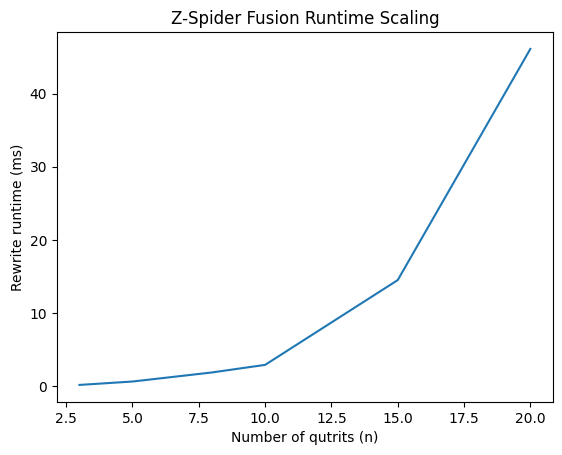

In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["n_qutrits"], df["time_ms_mean"])
plt.xlabel("Number of qutrits (n)")
plt.ylabel("Rewrite runtime (ms)")
plt.title("Z-Spider Fusion Runtime Scaling")
plt.show()

In [2]:
#TROTTERIZING HAMILTONIAN: H = alphaZ + betaX
import numpy as np
from scipy.linalg import expm

omega = np.exp(2j * np.pi / 3)

Z = np.diag([1, omega, omega**2])

X = np.array([[0,0,1],
              [1,0,0],
              [0,1,0]])

#exact unitary implementation of Hamiltonian 
def U_exact(alpha, beta, t):
    H = alpha*Z + beta*X
    return expm(-1j * t * H)

#trotterize using Strang-splitting to use Z-spider fusion rule for simplification 
def U_strang(alpha, beta, t, r):
    Uz_half = expm(-1j * (alpha * t/(2*r)) * Z)
    Ux = expm(-1j * (beta * t/r) * X)
    step = Uz_half @ Ux @ Uz_half
    U = np.eye(3, dtype=complex)
    for _ in range(r):
        U = U @ step
    return U

def strang_error(alpha, beta, t, r):
    Ue = U_exact(alpha, beta, t)
    Ut = U_strang(alpha, beta, t, r)

    # global phase stuff
    phi = np.angle(np.trace(Ue.conj().T @ Ut))
    Ut = Ut * np.exp(-1j * phi)

    return np.linalg.norm(Ue - Ut)

Strang splitting error for H = alpha Z + beta X (1 qutrit)
alpha=1.0, beta=0.7, t=1.0
 r | error
----|----------------
 1 | 2.899285e-01
 2 | 7.162600e-02
 3 | 3.182622e-02
 5 | 1.145834e-02
 8 | 4.476171e-03
10 | 2.864793e-03
15 | 1.273262e-03
20 | 7.162137e-04
30 | 3.183185e-04
40 | 1.790544e-04
60 | 7.957983e-05


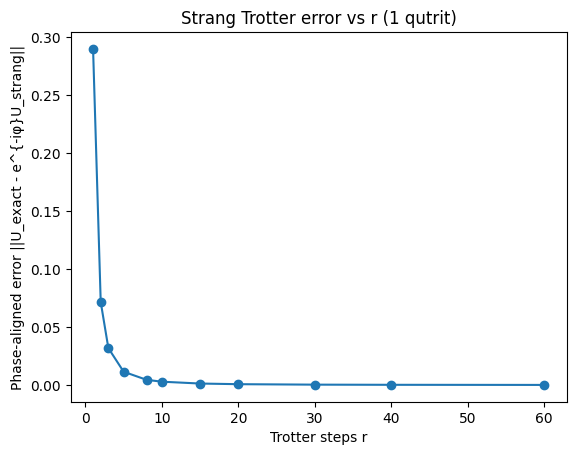

In [4]:
import matplotlib.pyplot as plt
#choosing parameters
alpha = 1.0
beta = 0.7
t = 1.0

# trotter step counts
rs = [1, 2, 3, 5, 8, 10, 15, 20, 30, 40, 60]

errs = [strang_error(alpha, beta, t, r) for r in rs]

#table
print("Strang splitting error for H = alpha Z + beta X (1 qutrit)")
print(f"alpha={alpha}, beta={beta}, t={t}")
print(" r | error")
print("----|----------------")
for r, e in zip(rs, errs):
    print(f"{r:>2d} | {e:.6e}")

# plot
plt.figure()
plt.plot(rs, errs, marker="o")
plt.xlabel("Trotter steps r")
plt.ylabel("Phase-aligned error ||U_exact - e^{-iφ}U_strang||")
plt.title("Strang Trotter error vs r (1 qutrit)")
plt.show()